In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

Part A – One-Line Answers

1. What are Supervised Learning Algorithms?
Supervised learning algorithms learn from labeled data to predict outputs for new inputs.

2. Difference between Regression and Classification Algorithms.
Regression predicts continuous values, while classification predicts categorical classes.

3. Explain Simple Linear Regression.
Simple Linear Regression predicts a continuous value using one independent variable and a straight-line relationship.

4. List the Assumptions of Linear Regression.
Linear regression assumes linearity, independence, homoscedasticity, normality of residuals, and no multicollinearity.

5. What is Bias–Variance Trade-Off?
The bias–variance trade-off is balancing underfitting (high bias) and overfitting (high variance) to improve model performance.

6. Explain Overfitting and Underfitting with examples.
Overfitting learns noise and performs poorly on new data, while underfitting is too simple to capture patterns (e.g., a high-degree polynomial vs. a straight line for curved data).

In [2]:
df = pd.read_csv("/content/RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(4200, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None
            house_id    area_sqft     bedrooms    bathrooms  location_score  \
count    4200.000000  4200.0000

In [5]:
X = df[['area_sqft',
        'bedrooms',
        'bathrooms',
        'location_score',
        'age_years']]

y = df['house_price_inr']

In [6]:
print("Independent Variables")
print(X.head())

print("\nDependent Variable")
print(y.head())

Independent Variables
   area_sqft  bedrooms  bathrooms  location_score  age_years
0       1973         5          4             7.6         23
1       1560         3          3             6.3         13
2       2071         4          3             5.8          9
3       2640         5          3             7.7         12
4       1498         3          3             3.8         15

Dependent Variable
0    40275084
1    26812029
2    29315677
3    47712959
4    17724566
Name: house_price_inr, dtype: int64


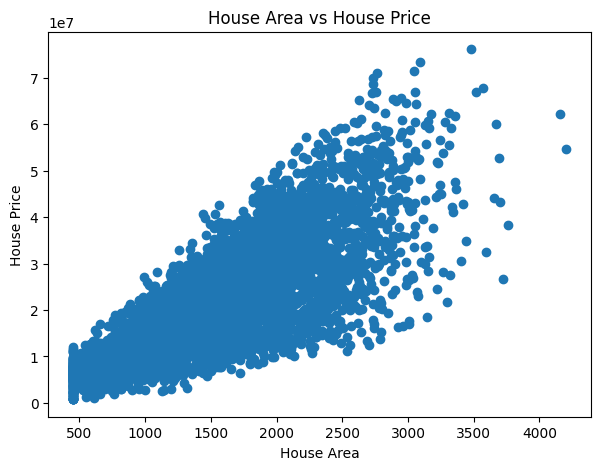

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(df['area_sqft'], df['house_price_inr'])
plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("House Area vs House Price")
plt.show()

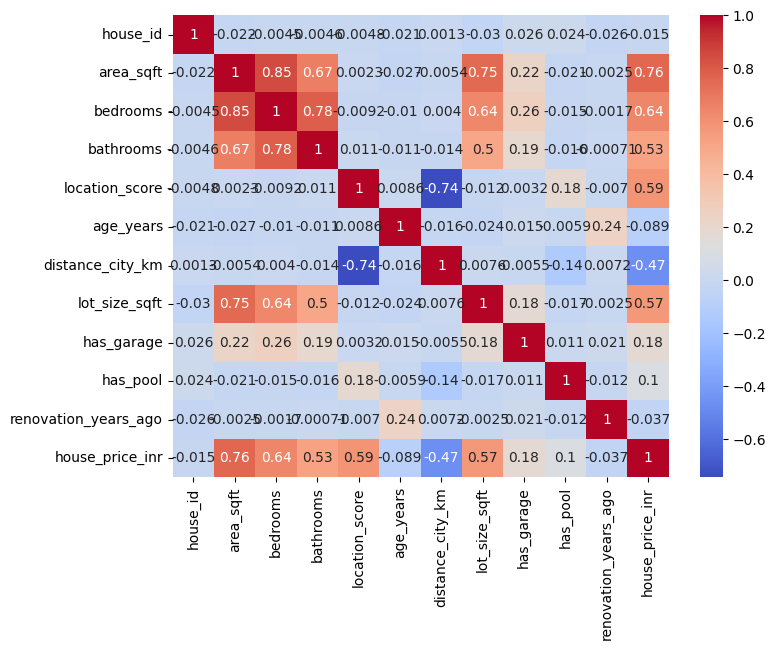

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(3360, 5)
(840, 5)
(3360,)
(840,)


In [13]:
from sklearn.linear_model import LinearRegression

In [15]:
X_simple = df[['area_sqft']]
y = df['house_price_inr']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()

In [18]:
model.fit(X_train, y_train)

LinearRegression()

In [19]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 14788.306111307542
Intercept: -1163519.1764186136


In [21]:
y_pred = model.predict(X_test)

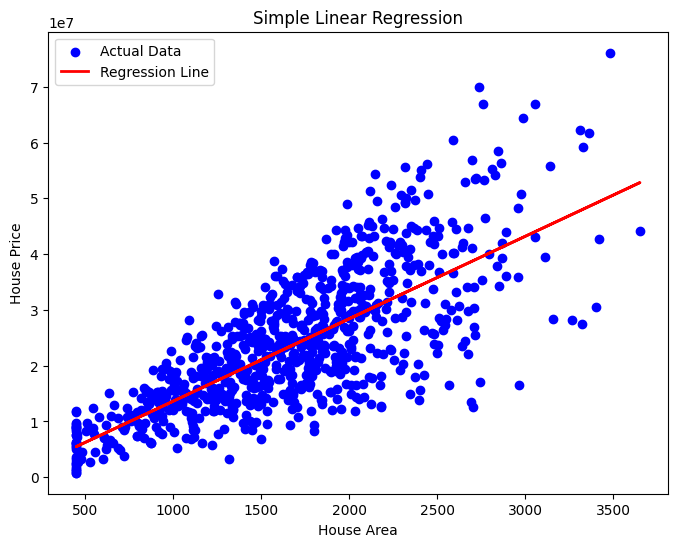

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')

plt.plot(X_test,
         y_pred,
         color='red',
         linewidth=2,
         label='Regression Line')

plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")

plt.legend()

plt.show()

In [23]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 14788.306111307542
Intercept: -1163519.1764186136


In [25]:
residuals = y_test - y_pred
residuals

,house_price_inr
1743,2.488629e+06
2196,5.032933e+05
1728,-1.145006e+07
3337,9.010054e+06
298,-1.285058e+07
...,...
152,4.218016e+06
1948,1.031369e+07
2751,-1.625130e+07
2148,6.517926e+05


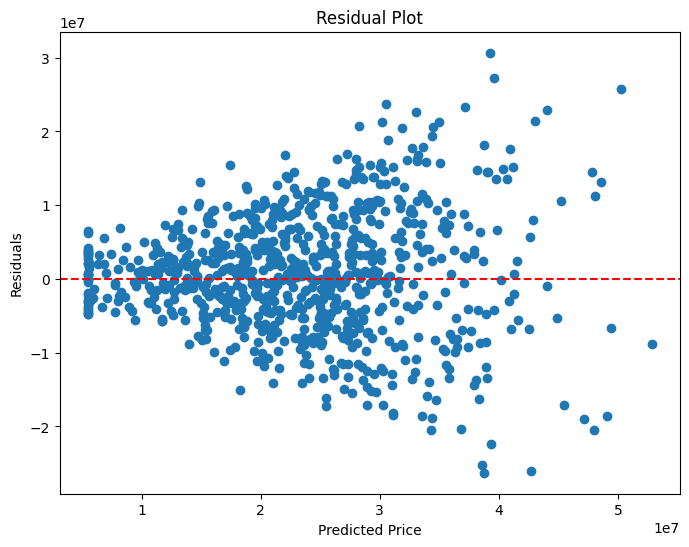

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0,
            color='red',
            linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [27]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

In [29]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 66989260021849.47


In [30]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 6294593.696131912


In [31]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 8184696.696997969


In [32]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5625199587991578


In [33]:
n = len(y_test)
p = 1

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.5619979062440257


In [34]:
print("------ Model Evaluation ------")

print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)
print("Adjusted R² :", adjusted_r2)

------ Model Evaluation ------
MSE : 66989260021849.47
MAE : 6294593.696131912
RMSE : 8184696.696997969
R² Score : 0.5625199587991578
Adjusted R² : 0.5619979062440257


multiple linear regression


In [35]:
from sklearn.linear_model import LinearRegression

In [37]:
X = df[['area_sqft',
        'bedrooms',
        'bathrooms',
        'location_score',
        'age_years']]

y = df['house_price_inr']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
mlr = LinearRegression()

In [40]:
mlr.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred_multi = mlr.predict(X_test)

In [42]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mlr.coef_
})

print(coefficients)

          Feature   Coefficient
0       area_sqft  1.399138e+04
1        bedrooms  2.054683e+05
2       bathrooms  1.922325e+05
3  location_score  3.385623e+06
4       age_years -6.760766e+04


In [44]:
print("Intercept:", mlr.intercept_)

Intercept: -18359361.092585776


In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_multi = mean_squared_error(y_test, y_pred_multi)

mae_multi = mean_absolute_error(y_test, y_pred_multi)

rmse_multi = np.sqrt(mse_multi)

r2_multi = r2_score(y_test, y_pred_multi)

print("MSE :", mse_multi)
print("MAE :", mae_multi)
print("RMSE :", rmse_multi)
print("R² :", r2_multi)

MSE : 12848701729036.895
MAE : 2641320.376490701
RMSE : 3584508.5756679247
R² : 0.9160902723815278


In [47]:
n = len(y_test)
p = X.shape[1]

adjusted_r2_multi = 1 - ((1 - r2_multi) * (n - 1)) / (n - p - 1)

print("Adjusted R²:", adjusted_r2_multi)

Adjusted R²: 0.9155872164605539


In [48]:
comparison = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE", "R²", "Adjusted R²"],
    "Simple LR": [mse, mae, rmse, r2, adjusted_r2],
    "Multiple LR": [mse_multi, mae_multi, rmse_multi, r2_multi, adjusted_r2_multi]
})

print(comparison)

        Metric     Simple LR   Multiple LR
0          MSE  6.698926e+13  1.284870e+13
1          MAE  6.294594e+06  2.641320e+06
2         RMSE  8.184697e+06  3.584509e+06
3           R²  5.625200e-01  9.160903e-01
4  Adjusted R²  5.619979e-01  9.155872e-01


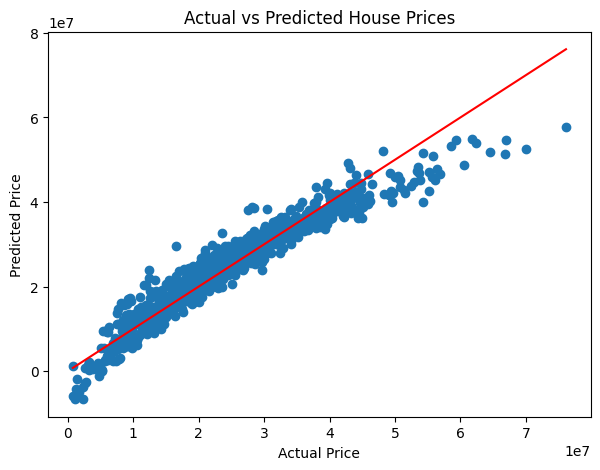

In [49]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_multi)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [50]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [52]:
X_poly = df[['area_sqft']]
y = df['house_price_inr']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

In [55]:
poly_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('linear', LinearRegression())])

In [56]:
y_pred_poly = poly_model.predict(X_test)

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_poly = mean_squared_error(y_test, y_pred_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)

rmse_poly = np.sqrt(mse_poly)

r2_poly = r2_score(y_test, y_pred_poly)

print("MSE :", mse_poly)
print("MAE :", mae_poly)
print("RMSE :", rmse_poly)
print("R² :", r2_poly)

MSE : 66962947122198.2
MAE : 6292394.561281703
RMSE : 8183089.094113433
R² : 0.5626917978136476


In [58]:
n = len(y_test)
p = 2  # Degree 2 polynomial

adjusted_r2_poly = 1 - ((1-r2_poly)*(n-1))/(n-p-1)

print("Adjusted R²:", adjusted_r2_poly)

Adjusted R²: 0.5616468558729395


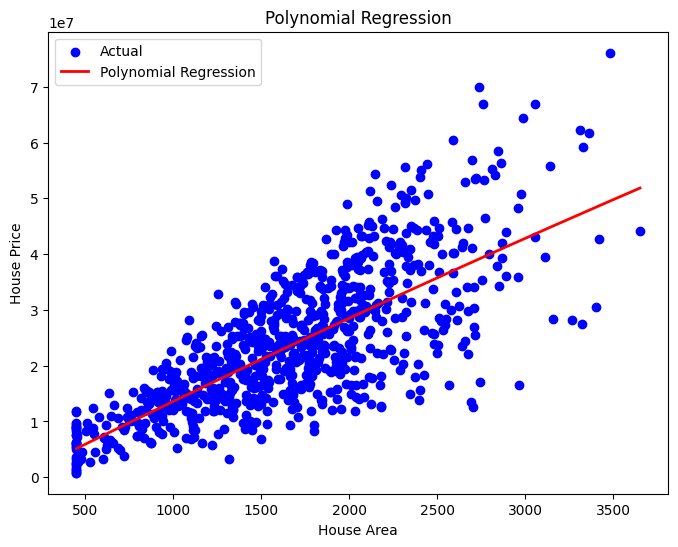

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='blue', label='Actual')

sorted_index = X_test['area_sqft'].argsort()

plt.plot(
    X_test.iloc[sorted_index],
    y_pred_poly[sorted_index],
    color='red',
    linewidth=2,
    label='Polynomial Regression'
)

plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("Polynomial Regression")

plt.legend()

plt.show()

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],
    "MSE": [
        mse,
        mse_multi,
        mse_poly
    ],
    "MAE": [
        mae,
        mae_multi,
        mae_poly
    ],
    "RMSE": [
        rmse,
        rmse_multi,
        rmse_poly
    ],
    "R² Score": [
        r2,
        r2_multi,
        r2_poly
    ]
})

print(comparison)

                        Model           MSE           MAE          RMSE  \
0    Simple Linear Regression  6.698926e+13  6.294594e+06  8.184697e+06   
1  Multiple Linear Regression  1.284870e+13  2.641320e+06  3.584509e+06   
2       Polynomial Regression  6.696295e+13  6.292395e+06  8.183089e+06   

   R² Score  
0  0.562520  
1  0.916090  
2  0.562692  


In [63]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       Multiple Linear Regression
MSE              12848701729036.894531
MAE                     2641320.376491
RMSE                    3584508.575668
R² Score                       0.91609
Name: 1, dtype: object


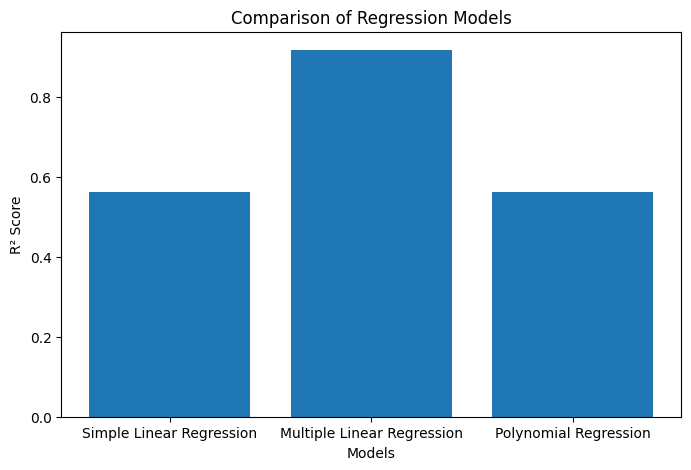

In [64]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models")

plt.show()